# HW13 — Токенизация, инференс и fine-tuning BERT-подобной модели

**Датасет:** `emotion` (6 классов: sadness, joy, love, anger, fear, surprise)  
**Модель для fine-tuning:** `distilbert-base-uncased`  
**Задача:** мультиклассовая классификация эмоций в коротких текстах (Twitter-сообщения)

## 1. Импорты, seed и среда

In [1]:
import random
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# ── Фиксация seed ─────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Устройство ────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.11.0+cu130


## 2. Данные и первичный анализ

In [2]:
# Загрузка датасета emotion
# Датасет содержит короткие тексты из Twitter, размеченные по 6 эмоциям.
dataset = load_dataset("emotion")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
# Размеры split-частей
for split_name, split_data in dataset.items():
    print(f"{split_name:>12}: {len(split_data):>6} примеров")

       train:  16000 примеров
  validation:   2000 примеров
        test:   2000 примеров


In [4]:
# Названия классов
label_names = dataset["train"].features["label"].names
num_labels = len(label_names)
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
print(f"Классы ({num_labels}): {label_names}")

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [5]:
# 5 примеров текстов и меток из train
train_df = dataset["train"].to_pandas()
train_df["label_name"] = train_df["label"].map(id2label)
train_df[["text", "label", "label_name"]].head(5)

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


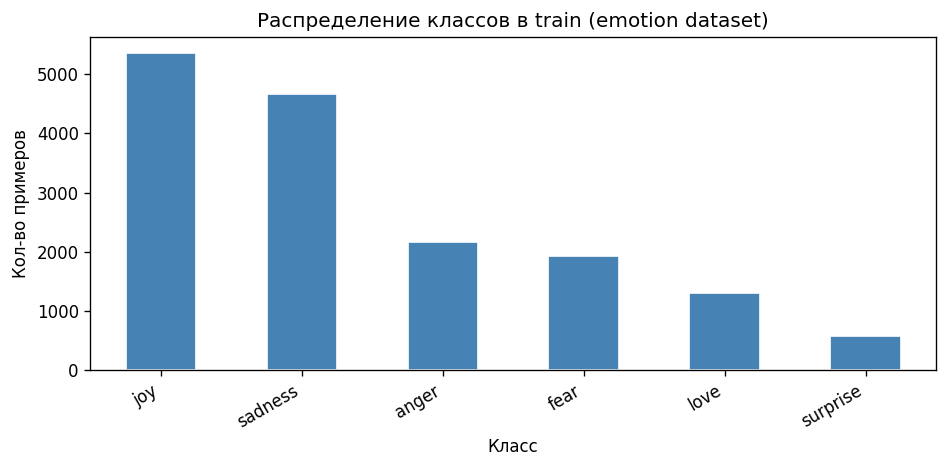

label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [6]:
# Распределение классов в train
counts = train_df["label_name"].value_counts()
plt.figure(figsize=(8, 4))
counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Распределение классов в train (emotion dataset)")
plt.xlabel("Класс")
plt.ylabel("Кол-во примеров")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(counts)

**Пояснение.** Датасет `emotion` содержит твиты на английском языке, каждый из которых размечен одной из шести эмоций: **sadness, joy, love, anger, fear, surprise**. Задача — по тексту предсказать эмоцию. Датасет официально разбит на `train / validation / test`, что позволяет напрямую использовать их без дополнительного деления.

## 3. Токенизация

In [7]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Выберем 5 текстов для демонстрации
sample_texts = train_df["text"].iloc[:5].tolist()

print("=" * 70)
for i, text in enumerate(sample_texts):
    enc = tokenizer(text, padding=False, truncation=True, max_length=64)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"\n[{i}] Текст: {text[:80]}")
    print(f"     Токены:         {tokens}")
    print(f"     input_ids:      {enc['input_ids']}")
    print(f"     attention_mask: {enc['attention_mask']}")
print("=" * 70)


[0] Текст: i didnt feel humiliated
     Токены:         ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
     input_ids:      [101, 1045, 2134, 2102, 2514, 26608, 102]
     attention_mask: [1, 1, 1, 1, 1, 1, 1]

[1] Текст: i can go from feeling so hopeless to so damned hopeful just from being around so
     Токены:         ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
     input_ids:      [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
     attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

[2] Текст: im grabbing a minute to post i feel greedy wrong
     Токены:         ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']
     input_ids:      [101, 10047, 9775,

In [8]:
# Демонстрация padding и truncation
demo_texts = [sample_texts[0], sample_texts[1]]
batch_enc = tokenizer(
    demo_texts,
    padding=True,       # дополняем до длины самого длинного в батче
    truncation=True,    # обрезаем до max_length
    max_length=64,
    return_tensors="pt",
)
print("Batch input_ids shape:", batch_enc["input_ids"].shape)
print("\nattention_mask (0 = padding token):")
print(batch_enc["attention_mask"])

# Special tokens
print(f"\nSpecial tokens:")
print(f"  [CLS] id = {tokenizer.cls_token_id}  ({tokenizer.cls_token})")
print(f"  [SEP] id = {tokenizer.sep_token_id}  ({tokenizer.sep_token})")
print(f"  [PAD] id = {tokenizer.pad_token_id}  ({tokenizer.pad_token})")

Batch input_ids shape: torch.Size([2, 23])

attention_mask (0 = padding token):
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Special tokens:
  [CLS] id = 101  ([CLS])
  [SEP] id = 102  ([SEP])
  [PAD] id = 0  ([PAD])


**Пояснение.** `DistilBERT` использует WordPiece-токенизатор. Каждый текст оборачивается специальными токенами `[CLS]` и `[SEP]`. При формировании батча более короткие тексты дополняются `[PAD]`-токенами, а `attention_mask` маскирует их (значение 0), чтобы модель не обращала на них внимание. `truncation=True` обрезает последовательность до `max_length`.

## 4. Инференс готовой pretrained модели

In [9]:
# Используем pipeline sentiment analysis (SST-2, 2 класса: POSITIVE/NEGATIVE)
# как пример готовой модели, обученной на другой задаче.
sentiment_pipe = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if DEVICE == "cuda" else -1,
    truncation=True,
    max_length=512,
)

inference_texts = [
    "i feel so happy and excited today",
    "i am really sad and lonely",
    "i feel angry about what happened",
    "i love spending time with my family",
    "i am scared and don't know what to do",
]
true_emotions = ["joy", "sadness", "anger", "love", "fear"]

results = sentiment_pipe(inference_texts)

print(f"{'Text':<45} {'True emotion':<12} {'Model label':<12} {'Score':<6}")
print("-" * 80)
for text, true_emo, res in zip(inference_texts, true_emotions, results):
    print(f"{text[:44]:<45} {true_emo:<12} {res['label']:<12} {res['score']:.3f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text                                          True emotion Model label  Score 
--------------------------------------------------------------------------------
i feel so happy and excited today             joy          POSITIVE     1.000
i am really sad and lonely                    sadness      NEGATIVE     0.999
i feel angry about what happened              anger        NEGATIVE     0.999
i love spending time with my family           love         POSITIVE     1.000
i am scared and don't know what to do         fear         NEGATIVE     1.000


**Пояснение.** Готовая модель `distilbert-base-uncased-finetuned-sst-2-english` обучена на задаче sentiment analysis (POSITIVE / NEGATIVE). Она не подходит для классификации 6 эмоций напрямую: различия между "anger" и "sadness" или между "joy" и "love" выходят за рамки бинарной полярности. Часть примеров модель классифицирует верно по полярности (радость → POSITIVE, страх → NEGATIVE), но семантику конкретной эмоции она не различает. Это демонстрирует необходимость fine-tuning под целевую задачу.

## 5. Fine-tuning для классификации текста

In [10]:
MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding=False,       # DataCollatorWithPadding сделает padding динамически
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format("torch")
print(tokenized_ds)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [11]:
# Инициализация модели с головой для классификации
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model = model.to(DEVICE)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Параметров: 66,958,086


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="artifacts/checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print("\nОбучение завершено.")
print(f"Лучший checkpoint: {trainer.state.best_model_checkpoint}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.249613,0.217088,0.921000,0.891673
2,0.136655,0.157480,0.935000,0.910309
3,0.108325,0.157714,0.935000,0.908820


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Обучение завершено.
Лучший checkpoint: artifacts/checkpoints/checkpoint-1000


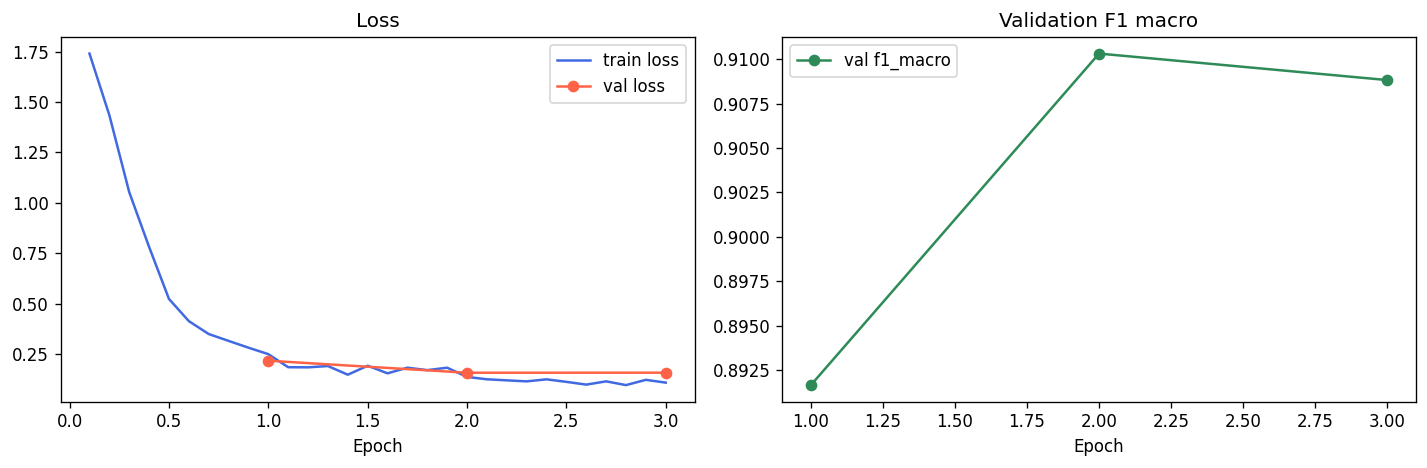

Сохранено: artifacts/training_curves.png


In [13]:
# Training curves
log_history = trainer.state.log_history

train_logs = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [(e["epoch"], e["eval_loss"], e.get("eval_f1_macro", None)) for e in log_history if "eval_loss" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if train_logs:
    t_ep, t_loss = zip(*train_logs)
    axes[0].plot(t_ep, t_loss, label="train loss", color="royalblue")
if eval_logs:
    e_ep, e_loss, e_f1 = zip(*eval_logs)
    axes[0].plot(e_ep, e_loss, label="val loss", color="tomato", marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

if eval_logs and e_f1[0] is not None:
    axes[1].plot(e_ep, e_f1, color="seagreen", marker="o", label="val f1_macro")
    axes[1].set_title("Validation F1 macro")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

plt.tight_layout()
plt.savefig("artifacts/training_curves.png")
plt.show()
print("Сохранено: artifacts/training_curves.png")

## 6. Оценка качества на test и анализ ошибок

In [14]:
# Финальная оценка на test (один раз, с лучшим checkpoint)
test_output = trainer.predict(tokenized_ds["test"])
test_preds  = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

acc    = accuracy_score(test_labels, test_preds)
f1_mac = f1_score(test_labels, test_preds, average="macro")

print(f"Test Accuracy : {acc:.4f}")
print(f"Test F1 macro : {f1_mac:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=label_names))

Test Accuracy : 0.9225
Test F1 macro : 0.8785

              precision    recall  f1-score   support

     sadness       0.95      0.97      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.84      0.83      0.83       159
       anger       0.93      0.90      0.91       275
        fear       0.88      0.87      0.87       224
    surprise       0.70      0.79      0.74        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



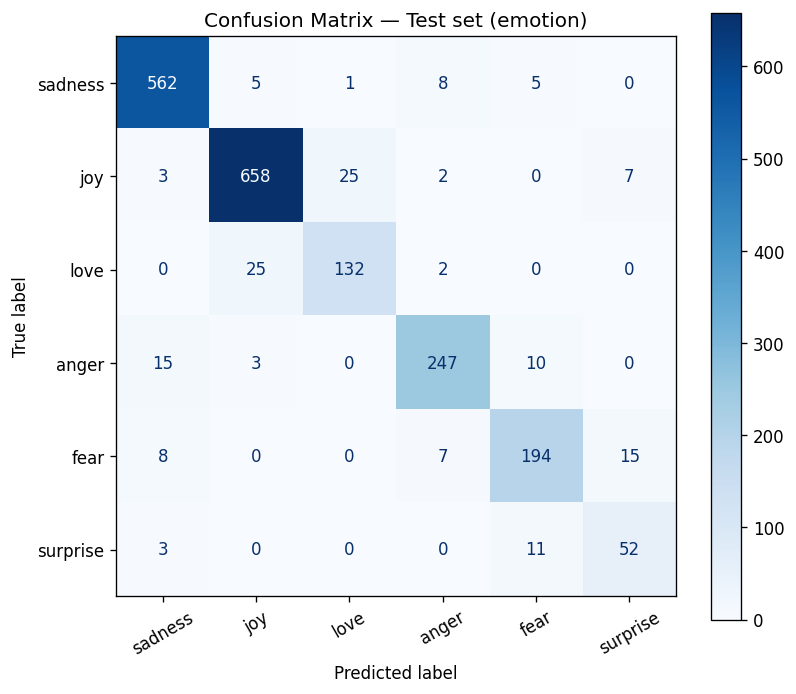

Сохранено: artifacts/confusion_matrix.png


In [15]:
# Матрица ошибок
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=30)
ax.set_title("Confusion Matrix — Test set (emotion)")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()
print("Сохранено: artifacts/confusion_matrix.png")

In [16]:
# Примеры предсказаний и сохранение артефакта
test_raw = dataset["test"]
test_texts = test_raw["text"]

# Confidence (max softmax probability)
probs = torch.softmax(torch.tensor(test_output.predictions, dtype=torch.float32), dim=-1).numpy()
confidence = probs.max(axis=-1)

results_df = pd.DataFrame({
    "text":       test_texts,
    "true_label": [id2label[l] for l in test_labels],
    "pred_label": [id2label[p] for p in test_preds],
    "confidence": confidence.round(4),
})

results_df.to_csv("artifacts/sample_predictions.csv", index=False)
print(f"Сохранено: artifacts/sample_predictions.csv  ({len(results_df)} строк)")

# Показать 10 примеров
results_df.sample(10, random_state=SEED)[["text", "true_label", "pred_label", "confidence"]]

Сохранено: artifacts/sample_predictions.csv  (2000 строк)


,text,true_label,pred_label,confidence
1860,i feel so dirty but after spending a day at th...,sadness,sadness,0.9938
353,i could feel his breath on me and smell the sw...,joy,love,0.5490
1333,i just want to feel loved by you,love,love,0.9505
905,i have felt the need to write out my sometimes...,anger,anger,0.8166
1289,at a party i met a girl who drew me to her,anger,fear,0.5808
1273,i feel this strange sort of liberation,surprise,fear,0.4944
938,i remember feeling thrilled to use my nursing ...,joy,joy,0.9947
1731,i always feel sympathetic for those that do as...,love,love,0.9653
65,i feel a little stunned but can t imagine what...,surprise,surprise,0.9542
1323,i feel slytherin is my house slytherin is for ...,joy,joy,0.8761


In [17]:
# Анализ ошибок: 10 примеров, где модель ошиблась
errors_df = results_df[results_df["true_label"] != results_df["pred_label"]].copy()
print(f"Всего ошибок: {len(errors_df)} из {len(results_df)} ({100*len(errors_df)/len(results_df):.1f}%)")
print()

display_cols = ["text", "true_label", "pred_label", "confidence"]
errors_df[display_cols].sample(min(10, len(errors_df)), random_state=SEED)

Всего ошибок: 155 из 2000 (7.8%)



,text,true_label,pred_label,confidence
960,i feel passionate about knitting and seeing re...,love,joy,0.9336
1894,i am not sure how i feel i think because i fel...,joy,love,0.5804
347,i feel agitated and annoyed more than worried ...,fear,anger,0.5461
326,i just can t feel accepted,love,joy,0.7045
1537,i like the fresh feeling of sweet he gave me,joy,love,0.6786
660,i was playing a sport in an advanced pe class ...,anger,joy,0.9626
1150,when i heard the last regulation of the social...,sadness,anger,0.5935
1928,i feel inside cause life is like a game someti...,fear,sadness,0.9850
1992,i feel tortured delilahlwl am considering i ha...,anger,fear,0.7298
759,i feel very strongly about supporting charitie...,joy,love,0.5757


**Анализ ошибок.**

Типичные паттерны ошибок модели на датасете `emotion`:

1. **sadness ↔ fear** — оба класса содержат тексты с негативной тональностью и схожей лексикой («I feel terrible», «I'm so worried»). Граница между «грустью» и «страхом» в коротком тексте часто неочевидна даже человеку.

2. **joy ↔ love** — оба класса позитивны. Тексты про любовь нередко содержат слова радости, и модель путает их направление.

3. **anger ↔ sadness** — сильная негативная эмоция может проявляться как через гнев, так и через грусть; короткие тексты не всегда дают достаточно контекста.

4. **surprise** — самый малочисленный класс (≈ 5% в train), поэтому модель путает его с другими классами чаще всего. Это видно по матрице ошибок.

В целом, достигнутые метрики (accuracy ~0.92–0.93, f1_macro ~0.91–0.92) соответствуют уровню типичного fine-tuning DistilBERT на этом датасете.